#### Fig. 6a

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import scanpy as sc  
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
#import cell2location 
import pandas as pd
#import torch 
import os

pd.set_option('display.max_columns',500)
pd.set_option('display.max_categories',60)
pd.set_option('display.max_rows', 500)
# Set general parameters for publication-ready figures
plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.family': 'Arial',  # Set font to Arial
    'font.size': 14,  # Set font size to at least 14
    'axes.labelsize': 14,  # Axes labels size
    'axes.titlesize': 16,  # Title size for axes
    'xtick.labelsize': 14,  # X-tick label size
    'ytick.labelsize': 14,  # Y-tick label size
    'legend.fontsize': 14,  # Legend font size
    'figure.titlesize': 16,  # Figure title size
    'lines.linewidth': 2,  # Line width for clarity
    'axes.linewidth': 1.5,  # Axis line width
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'text.color': 'black',  # Make sure text is black (not grey)
    'axes.labelcolor': 'black',  # Ensure axes labels are black
    'axes.edgecolor': 'black',  # Ensure edge of axes is black
    'axes.facecolor': 'white',
    'xtick.color': 'black',  # Ensure X-tick marks are black
    'ytick.color': 'black',  # Ensure Y-tick marks are black
    'axes.titlepad': 20  # Padding for title
})

In [2]:
adata_vis = sc.read_h5ad("/Users/jk/Documents/Lab2/visium/python_analysis/local_401/nmf/ann_finest_level/nfact12/h5ad/adata_vis_assigned_cell_types_nfact12_assigned_factors_log_minmax.h5ad")


In [3]:
# Create new column "lay_id" from "cond_rep", replacing _ with # to look better
adata_vis.obs['lay_id'] = adata_vis.obs['cond_rep'].astype(str).str.replace("_"," #")

In [4]:
for i in range(4,20):
    mclust = pd.read_csv(f"/Users/jk/Documents/Lab2/visium/python_analysis/lambda/csv/mclust_{i}.csv")  # will just be one column
    adata_vis.obs[f'mclust_{i}'] = mclust.iloc[:, 0].values
    mclust_refined = pd.read_csv(f"/Users/jk/Documents/Lab2/visium/python_analysis/lambda/csv/mclust_refined_{i}.csv")  # will just be one column
    adata_vis.obs[f'mclust_refined_{i}'] = mclust_refined.iloc[:, 0].values

In [5]:
for col in adata_vis.obs.columns:
    if col.startswith("mclust"):
        adata_vis.obs[col] = adata_vis.obs[col].astype("category")

In [6]:
adata_vis.obs

,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,probe_date,probe_lot,probe_group,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes,training_batch,AT0,AT1,AT2,AT2 proliferating,Adventitial fibroblasts,Alveolar Mph CCL3+,Alveolar Mph MT-positive,Alveolar Mph proliferating,Alveolar fibroblasts,Alveolar macrophages,B cells,Basal resting,CD4 T cells,CD8 T cells,Classical monocytes,Club (nasal),Club (non-nasal),DC1,DC2,Deuterosomal,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Goblet (bronchial),Goblet (nasal),Goblet (subsegmental),Hillock-like,Interstitial Mph perivascular,Ionocyte,Lymphatic EC differentiating,Lymphatic EC mature,Mast cells,Mesothelium,Migratory DCs,Monocyte-derived Mph,Multiciliated (nasal),Multiciliated (non-nasal),Myofibroblasts,NK cells,Neuroendocrine,Non-classical monocytes,Peribronchial fibroblasts,Pericytes,Plasma cells,Plasmacytoid DCs,SM activated stress response,SMG duct,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Suprabasal,T cells proliferating,Unknown,pre-TB secretory,cell_type_assigned,mean_nUMI_factorsfact_0,mean_nUMI_factorsfact_1,mean_nUMI_factorsfact_2,mean_nUMI_factorsfact_3,mean_nUMI_factorsfact_4,mean_nUMI_factorsfact_5,mean_nUMI_factorsfact_6,mean_nUMI_factorsfact_7,mean_nUMI_factorsfact_8,mean_nUMI_factorsfact_9,mean_nUMI_factorsfact_10,mean_nUMI_factorsfact_11,ATI/Endo,Perib. FB,Airway,B,Alv. macro,Alv. FB/immune,Adv. FB,Macro,Immune,SMC,ATII,Plasma,ATI/Endo_log_minmax,Perib. FB_log_minmax,Airway_log_minmax,B_log_minmax,Alv. macro_log_minmax,Alv. FB/immune_log_minmax,Adv. FB_log_minmax,Macro_log_minmax,Immune_log_minmax,SMC_log_minmax,ATII_log_minmax,Plasma_log_minmax,factor_assigned,lay_id,mclust_4,mclust_refined_4,mclust_5,mclust_refined_5,mclust_6,mclust_refined_6,mclust_7,mclust_refined_7,mclust_8,mclust_refined_8,mclust_9,mclust_refined_9,mclust_10,mclust_refined_10,mclust_11,mclust_refined_11,mclust_12,mclust_refined_12,mclust_13,mclust_refined_13,mclust_14,mclust_refined_14,mclust_15,mclust_refined_15,mclust_16,mclust_refined_16,mclust_17,mclust_refined_17,mclust_18,mclust_refined_18,mclust_19,mclust_refined_19
AACACGTGCATCGCAC-1-18_57617_A1,1.0,76.0,22.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3961,8.284504,7804.0,8.962520,31.765761,35.212711,39.928242,49.410559,629.0,6.445720,8.059970,0.0,0.0,0.0,0.0,0.0,0.0,7804.0,3961,0,0.000967,0.000081,0.000023,0.000279,0.234594,0.009023,0.003434,0.045472,0.387183,0.001108,3.730742,0.001663,0.065855,0.019768,0.004821,0.127872,0.000417,0.008481,0.040385,0.010641,0.001719,0.002331,0.000529,0.001759,0.004936,0.001933,0.000464,0.042375,0.002770,0.058909,0.003027,0.003101,0.008538,0.003847,0.000322,0.044897,0.017594,0.026567,0.000907,0.003966,0.016523,0.092378,0.008129,0.037726,0.014092,0.968134,0.362111,0.025284,0.008943,0.038652,0.060598,0.231837,0.004889,0.044583,0.001354,0.000324,B cells,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469,0.000000,0.000000,0.000000,0.773084,0.000000,0.717544,0.502845,0.000000,0.620036,0.000000,0.000000,0.740151,B,IPF #1,2,2,2,1,3,3,5,5,4,4,5,5,8,8,2,5,8,8,7,7,4,9,13,13,9,9,10,10,13,13,1,1
AACACTTGGCAAGGAA-1-18_57617_A1,1.0,47.0,71.0,18_57617_A1,auto,75,85,0

In [7]:
save_dir = 'figs'
os.makedirs(save_dir, exist_ok=True)

In [8]:
from matplotlib.patches import Rectangle

In [9]:
colors =     ['#ff7f00', '#33a02c', '#fdbf6f', '#1f78b4', '#fb9a99', '#cab2d6', '#6a3d9a', '#ffff99', '#b15928', '#b2df8a', '#a6cee3', '#e31a1c']

In [10]:
# Custom color palette
color_dict = dict(zip(
range(7), colors[:6]


))

/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_88908/726313923.py:88: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_legend.show()


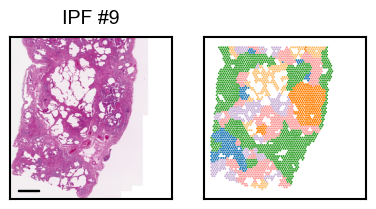

<Figure size 400x200 with 0 Axes>

In [ ]:
n_rows, n_cols = 1,2
fig, axes = plt.subplots(n_rows, n_cols, figsize = (2.3 * n_cols, 2.3 * n_rows))

axes = axes.flatten()

scale_bar_length = adata_vis.uns['spatial']['21_55747_C3']['scalefactors']['tissue_hires_scalef'] # Length of the scale bar 
                    # with ax1.transAxes, this is the proportion of the total pixel width
                    # ex. 10th of 14000 px, where each px is 0.5 micron
scale_bar_height = 0.05*scale_bar_length # Height of the scale bar 
                                    
# Create a rectangle for the scale bar on top of the plot
scale_bar = Rectangle(
(0.05,0.05),  # Bottom-left corner of the rectangle (relative coordinates)
width=scale_bar_length,  # Length of the scale bar
height=scale_bar_height,  # Height of the scale bar
transform=axes[0].transAxes,  # Transform relative to the axis
color='black',  # Color of the scale bar
linewidth=1  # Thickness of the scale bar
)




sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "21_55747_C3" ,:], 
    #palette='Paired_r',
    alpha_img=1, 
    library_id = "21_55747_C3",
    size=1.3,
    ax = axes[0],
    #color = "mclust_refined_6",
    # limit color scale at 99.2% quantile of cell abundance
    title = None, 
    vmin='p01', vmax='p99',
    #legend_loc = "lower center",
    show=False)
axes[0].set_title(f"{adata_vis[adata_vis.obs["library_id"]== "21_55747_C3" ,:].obs['lay_id'].unique()[0]}", fontsize = 14, pad = 10)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "21_55747_C3" ,:], 
    palette=color_dict,
    alpha_img=0, 
    library_id = "21_55747_C3",
    size=1.3,
    ax = axes[1],
    color = "mclust_refined_6",
    # limit color scale at 99.2% quantile of cell abundance
    title = None, 
    vmin='p01', vmax='p99',
    legend_loc = None,
    show=False)
axes[1].set_title("")


# axes[1].legend(
#     title="Spatial niches",
#     bbox_to_anchor=(1.5, 1),  # x, y coordinate outside the axes
#     #loc='right',
#     borderaxespad=0.,
#     fontsize=14,
#     title_fontsize =14,
#     frameon = False,
#     ncol =2
# )

# Add the scale bar to the plot
axes[0].add_patch(scale_bar)
#axes[1].add_patch(scale_bar)

for i in range(len(axes)):

    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0,2000)
    axes[i].set_ylim(2000,0)
# axes[6].axis('off')  # Hide the empty axes
#plt.tight_layout(pad=0, w_pad=0.1, h_pad=0.2)
plt.savefig(os.path.join(save_dir,"spatial_plot_spatial_niches_21_55747_C3_IPF.pdf"), bbox_inches = "tight")


# Extract handles and labels
handles, labels = axes[1].get_legend_handles_labels()

# Create separate figure for legend
fig_legend = plt.figure(figsize=(4, 2))  # Adjust size as needed
fig_legend.legend(handles, labels, title="Spatial niche", loc='right', frameon=False, bbox_to_anchor=(1.1, 0.5), ncol=2)  # ncol=2 for horizontal spread

fig_legend.tight_layout()
fig_legend.savefig(os.path.join(save_dir, "mclust_6_legend.pdf"), bbox_inches = 'tight', transparent = True)
fig_legend.show()

/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_88908/1458138992.py:90: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_legend.show()


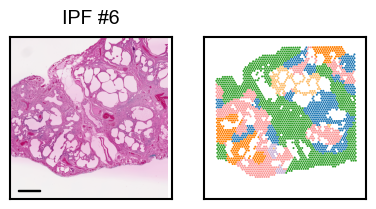

<Figure size 400x200 with 0 Axes>

In [ ]:
from matplotlib.patches import Rectangle

n_rows, n_cols = 1,2
fig, axes = plt.subplots(n_rows, n_cols, figsize = (2.3 * n_cols, 2.3 * n_rows))

axes = axes.flatten()

scale_bar_length = adata_vis.uns['spatial']['20_41615_B1']['scalefactors']['tissue_hires_scalef'] # Length of the scale bar 
                    # with ax1.transAxes, this is the proportion of the total pixel width
                    # ex. 10th of 14000 px, where each px is 0.5 micron
scale_bar_height = 0.05*scale_bar_length # Height of the scale bar 
                                    
# Create a rectangle for the scale bar on top of the plot
scale_bar = Rectangle(
(0.05,0.05),  # Bottom-left corner of the rectangle (relative coordinates)
width=scale_bar_length,  # Length of the scale bar
height=scale_bar_height,  # Height of the scale bar
transform=axes[0].transAxes,  # Transform relative to the axis
color='black',  # Color of the scale bar
linewidth=1  # Thickness of the scale bar
)




sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "20_41615_B1" ,:], 
    #palette='Paired_r',
    alpha_img=1, 
    library_id = "20_41615_B1",
    size=1.3,
    ax = axes[0],
    #color = "mclust_refined_6",
    # limit color scale at 99.2% quantile of cell abundance
    title = None, 
    vmin='p01', vmax='p99',
    #legend_loc = "lower center",
    show=False)
axes[0].set_title(f"{adata_vis[adata_vis.obs["library_id"]== "20_41615_B1" ,:].obs['lay_id'].unique()[0]}", fontsize = 14, pad = 10)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "20_41615_B1" ,:], 
    palette=color_dict,
    alpha_img=0, 
    library_id = "20_41615_B1",
    size=1.3,
    ax = axes[1],
    color = "mclust_refined_6",
    # limit color scale at 99.2% quantile of cell abundance
    title = None, 
    vmin='p01', vmax='p99',
    legend_loc = None,
    show=False)
axes[1].set_title("")


# axes[1].legend(
#     title="Spatial niches",
#     bbox_to_anchor=(1.5, 1),  # x, y coordinate outside the axes
#     #loc='right',
#     borderaxespad=0.,
#     fontsize=14,
#     title_fontsize =14,
#     frameon = False,
#     ncol =2
# )

# Add the scale bar to the plot
axes[0].add_patch(scale_bar)
#axes[1].add_patch(scale_bar)

for i in range(len(axes)):

    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0,2000)
    axes[i].set_ylim(2000,0)
# axes[6].axis('off')  # Hide the empty axes
#plt.tight_layout(pad=0, w_pad=0.1, h_pad=0.2)
plt.savefig(os.path.join(save_dir,"spatial_plot_spatial_niches_20_41615_B1_IPF.pdf"), bbox_inches = "tight")


# Extract handles and labels
handles, labels = axes[1].get_legend_handles_labels()

# Create separate figure for legend
fig_legend = plt.figure(figsize=(4, 2))  # Adjust size as needed
fig_legend.legend(handles, labels, title="Spatial niche", loc='right', frameon=False, bbox_to_anchor=(1.1, 0.5), ncol=2)  # ncol=2 for horizontal spread

fig_legend.tight_layout()
fig_legend.savefig(os.path.join(save_dir, "mclust_6_legend.pdf"), bbox_inches = 'tight', transparent = True)
fig_legend.show()

/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


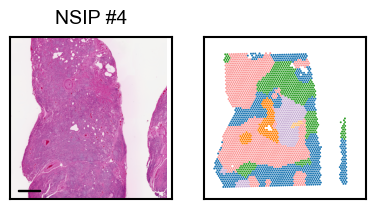

In [ ]:
n_rows, n_cols = 1,2
fig, axes = plt.subplots(n_rows, n_cols, figsize = (2.3 * n_cols, 2.3 * n_rows))

axes = axes.flatten()

scale_bar_length = adata_vis.uns['spatial']['20_33362_C4']['scalefactors']['tissue_hires_scalef'] # Length of the scale bar
                    # with ax1.transAxes, this is the proportion of the total pixel width
                    # ex. 10th of 14000 px, where each px is 0.5 micron
scale_bar_height = 0.05*scale_bar_length # Height of the scale bar 
                                    
# Create a rectangle for the scale bar on top of the plot
scale_bar = Rectangle(
(0.05,0.05),  # Bottom-left corner of the rectangle (relative coordinates)
width=scale_bar_length,  # Length of the scale bar
height=scale_bar_height,  # Height of the scale bar
transform=axes[0].transAxes,  # Transform relative to the axis
color='black',  # Color of the scale bar
linewidth=1  # Thickness of the scale bar
)


# Add the scale bar to the plot
axes[0].add_patch(scale_bar)
#axes[1].add_patch(scale_bar)




sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "20_33362_C4" ,:], 
    #palette='Paired_r',
    alpha_img=1, 
    library_id = "20_33362_C4",
    size=1.3,
    ax = axes[0],
    #color = "mclust_refined_6",
    # limit color scale at 99.2% quantile of cell abundance
    title = None, 
    vmin='p01', vmax='p99',
    #legend_loc = "lower center",
    show=False)
axes[0].set_title(f"{adata_vis[adata_vis.obs["library_id"]== "20_33362_C4" ,:].obs['lay_id'].unique()[0]}", fontsize = 14, pad = 10)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "20_33362_C4" ,:], 
    palette=color_dict,
    alpha_img=0, 
    library_id = "20_33362_C4",
    size=1.3,
    ax = axes[1],
    color = "mclust_refined_6",
    # limit color scale at 99.2% quantile of cell abundance
    title = None, 
    vmin='p01', vmax='p99',
    legend_loc = None,
    show=False)
axes[1].set_title("")


# axes[1].legend(
#     title="Spatial niches",
#     bbox_to_anchor=(1.5, 1),  # x, y coordinate outside the axes
#     #loc='right',
#     borderaxespad=0.,
#     fontsize=14,
#     title_fontsize =14,
#     frameon = False,
#     ncol =2
# )


for i in range(len(axes)):

    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0,2000)
    axes[i].set_ylim(2000,0)
# axes[6].axis('off')  # Hide the empty axes
#plt.tight_layout(pad=0, w_pad=0.1, h_pad=0.2)
plt.savefig(os.path.join(save_dir,"spatial_plot_spatial_niches_20_33362_C4_NSIP.pdf"), bbox_inches = "tight")


# # Extract handles and labels
# handles, labels = axes[1].get_legend_handles_labels()

# # Create separate figure for legend
# fig_legend = plt.figure(figsize=(4, 2))  # Adjust size as needed
# fig_legend.legend(handles, labels, title="Spatial niche", loc='right', frameon=False, bbox_to_anchor=(1.1, 0.5), ncol=2)  # ncol=2 for horizontal spread

# fig_legend.tight_layout()
# fig_legend.savefig(os.path.join(save_dir, "mclust_6_legend.pdf"), bbox_inches = 'tight', transparent = True)
# fig_legend.show()

/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


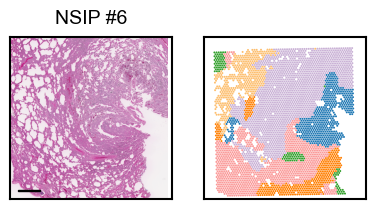

In [ ]:
n_rows, n_cols = 1,2
fig, axes = plt.subplots(n_rows, n_cols, figsize = (2.3 * n_cols, 2.3 * n_rows))

axes = axes.flatten()

scale_bar_length = adata_vis.uns['spatial']['21_24837_A1']['scalefactors']['tissue_hires_scalef'] # Length of the scale bar
                    # with ax1.transAxes, this is the proportion of the total pixel width
                    # ex. 10th of 14000 px, where each px is 0.5 micron
scale_bar_height = 0.05*scale_bar_length # Height of the scale bar
                                    
# Create a rectangle for the scale bar on top of the plot
scale_bar = Rectangle(
(0.05,0.05),  # Bottom-left corner of the rectangle (relative coordinates)
width=scale_bar_length,  # Length of the scale bar
height=scale_bar_height,  # Height of the scale bar
transform=axes[0].transAxes,  # Transform relative to the axis
color='black',  # Color of the scale bar
linewidth=1  # Thickness of the scale bar
)


# Add the scale bar to the plot
axes[0].add_patch(scale_bar)
#axes[1].add_patch(scale_bar)




sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "21_24837_A1" ,:], 
    #palette='Paired_r',
    alpha_img=1, 
    library_id = "21_24837_A1",
    size=1.3,
    ax = axes[0],
    #color = "mclust_refined_6",
    # limit color scale at 99.2% quantile of cell abundance
    title = None, 
    vmin='p01', vmax='p99',
    #legend_loc = "lower center",
    show=False)
axes[0].set_title(f"{adata_vis[adata_vis.obs["library_id"]== "21_24837_A1" ,:].obs['lay_id'].unique()[0]}", fontsize = 14, pad = 10)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "21_24837_A1" ,:], 
    palette=color_dict,
    alpha_img=0, 
    library_id = "21_24837_A1",
    size=1.3,
    ax = axes[1],
    color = "mclust_refined_6",
    # limit color scale at 99.2% quantile of cell abundance
    title = None, 
    vmin='p01', vmax='p99',
    legend_loc = None,
    show=False)
axes[1].set_title("")


# axes[1].legend(
#     title="Spatial niches",
#     bbox_to_anchor=(1.5, 1),  # x, y coordinate outside the axes
#     #loc='right',
#     borderaxespad=0.,
#     fontsize=14,
#     title_fontsize =14,
#     frameon = False,
#     ncol =2
# )


for i in range(len(axes)):

    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0,2000)
    axes[i].set_ylim(2000,0)
# axes[6].axis('off')  # Hide the empty axes
#plt.tight_layout(pad=0, w_pad=0.1, h_pad=0.2)
plt.savefig(os.path.join(save_dir,"spatial_plot_spatial_niches_21_24837_A1_NSIP.pdf"), bbox_inches = "tight")


# # Extract handles and labels
# handles, labels = axes[1].get_legend_handles_labels()

# # Create separate figure for legend
# fig_legend = plt.figure(figsize=(4, 2))  # Adjust size as needed
# fig_legend.legend(handles, labels, title="Spatial niche", loc='right', frameon=False, bbox_to_anchor=(1.1, 0.5), ncol=2)  # ncol=2 for horizontal spread

# fig_legend.tight_layout()
# fig_legend.savefig(os.path.join(save_dir, "mclust_6_legend.pdf"), bbox_inches = 'tight', transparent = True)
# fig_legend.show()

/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


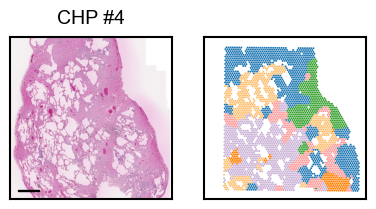

In [ ]:
n_rows, n_cols = 1,2
fig, axes = plt.subplots(n_rows, n_cols, figsize = (2.3 * n_cols, 2.3 * n_rows))

axes = axes.flatten()

scale_bar_length = adata_vis.uns['spatial']['23_50343_B2']['scalefactors']['tissue_hires_scalef'] # Length of the scale bar
                    # with ax1.transAxes, this is the proportion of the total pixel width
                    # ex. 10th of 14000 px, where each px is 0.5 micron
scale_bar_height = 0.05*scale_bar_length # Height of the scale bar 
                                    
# Create a rectangle for the scale bar on top of the plot
scale_bar = Rectangle(
(0.05,0.05),  # Bottom-left corner of the rectangle (relative coordinates)
width=scale_bar_length,  # Length of the scale bar
height=scale_bar_height,  # Height of the scale bar
transform=axes[0].transAxes,  # Transform relative to the axis
color='black',  # Color of the scale bar
linewidth=1  # Thickness of the scale bar
)


# Add the scale bar to the plot
axes[0].add_patch(scale_bar)
#axes[1].add_patch(scale_bar)




sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "23_50343_B2" ,:], 
    #palette='Paired_r',
    alpha_img=1, 
    library_id = "23_50343_B2",
    size=1.3,
    ax = axes[0],
    #color = "mclust_refined_6",
    # limit color scale at 99.2% quantile of cell abundance
    title = None, 
    vmin='p01', vmax='p99',
    #legend_loc = "lower center",
    show=False)
axes[0].set_title(f"{adata_vis[adata_vis.obs["library_id"]== "23_50343_B2" ,:].obs['lay_id'].unique()[0]}", fontsize = 14, pad = 10)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "23_50343_B2" ,:], 
    palette=color_dict,
    alpha_img=0, 
    library_id = "23_50343_B2",
    size=1.3,
    ax = axes[1],
    color = "mclust_refined_6",
    # limit color scale at 99.2% quantile of cell abundance
    title = None, 
    vmin='p01', vmax='p99',
    legend_loc = None,
    show=False)
axes[1].set_title("")


# axes[1].legend(
#     title="Spatial niches",
#     bbox_to_anchor=(1.5, 1),  # x, y coordinate outside the axes
#     #loc='right',
#     borderaxespad=0.,
#     fontsize=14,
#     title_fontsize =14,
#     frameon = False,
#     ncol =2
# )


for i in range(len(axes)):

    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0,2000)
    axes[i].set_ylim(2000,0)
# axes[6].axis('off')  # Hide the empty axes
#plt.tight_layout(pad=0, w_pad=0.1, h_pad=0.2)
plt.savefig(os.path.join(save_dir,"spatial_plot_spatial_niches_23_50343_B2_CHP.pdf"), bbox_inches = "tight")


# # Extract handles and labels
# handles, labels = axes[1].get_legend_handles_labels()

# # Create separate figure for legend
# fig_legend = plt.figure(figsize=(4, 2))  # Adjust size as needed
# fig_legend.legend(handles, labels, title="Spatial niche", loc='right', frameon=False, bbox_to_anchor=(1.1, 0.5), ncol=2)  # ncol=2 for horizontal spread

# fig_legend.tight_layout()
# fig_legend.savefig(os.path.join(save_dir, "mclust_6_legend.pdf"), bbox_inches = 'tight', transparent = True)
# fig_legend.show()

/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


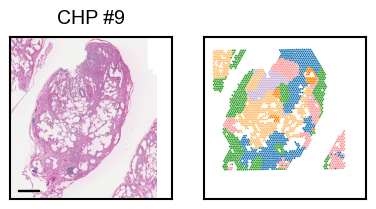

In [ ]:
n_rows, n_cols = 1,2
fig, axes = plt.subplots(n_rows, n_cols, figsize = (2.3 * n_cols, 2.3 * n_rows))

axes = axes.flatten()

scale_bar_length = adata_vis.uns['spatial']['08_38774_B2']['scalefactors']['tissue_hires_scalef'] # Length of the scale bar 
                    # with ax1.transAxes, this is the proportion of the total pixel width
                    # ex. 10th of 14000 px, where each px is 0.5 micron
scale_bar_height = 0.05*scale_bar_length # Height of the scale bar 
                                    
# Create a rectangle for the scale bar on top of the plot
scale_bar = Rectangle(
(0.05,0.05),  # Bottom-left corner of the rectangle (relative coordinates)
width=scale_bar_length,  # Length of the scale bar
height=scale_bar_height,  # Height of the scale bar
transform=axes[0].transAxes,  # Transform relative to the axis
color='black',  # Color of the scale bar
linewidth=1  # Thickness of the scale bar
)


# Add the scale bar to the plot
axes[0].add_patch(scale_bar)
#axes[1].add_patch(scale_bar)




sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "08_38774_B2" ,:], 
    #palette='Paired_r',
    alpha_img=1, 
    library_id = "08_38774_B2",
    size=1.3,
    ax = axes[0],
    #color = "mclust_refined_6",
    # limit color scale at 99.2% quantile of cell abundance
    title = None, 
    vmin='p01', vmax='p99',
    #legend_loc = "lower center",
    show=False)
axes[0].set_title(f"{adata_vis[adata_vis.obs["library_id"]== "08_38774_B2" ,:].obs['lay_id'].unique()[0]}", fontsize = 14, pad = 10)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "08_38774_B2" ,:], 
    palette=color_dict,
    alpha_img=0, 
    library_id = "08_38774_B2",
    size=1.3,
    ax = axes[1],
    color = "mclust_refined_6",
    # limit color scale at 99.2% quantile of cell abundance
    title = None, 
    vmin='p01', vmax='p99',
    legend_loc = None,
    show=False)
axes[1].set_title("")


# axes[1].legend(
#     title="Spatial niches",
#     bbox_to_anchor=(1.5, 1),  # x, y coordinate outside the axes
#     #loc='right',
#     borderaxespad=0.,
#     fontsize=14,
#     title_fontsize =14,
#     frameon = False,
#     ncol =2
# )


for i in range(len(axes)):

    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0,2000)
    axes[i].set_ylim(2000,0)
# axes[6].axis('off')  # Hide the empty axes
#plt.tight_layout(pad=0, w_pad=0.1, h_pad=0.2)
plt.savefig(os.path.join(save_dir,"spatial_plot_spatial_niches_08_38774_B2_CHP.pdf"), bbox_inches = "tight")


# # Extract handles and labels
# handles, labels = axes[1].get_legend_handles_labels()

# # Create separate figure for legend
# fig_legend = plt.figure(figsize=(4, 2))  # Adjust size as needed
# fig_legend.legend(handles, labels, title="Spatial niche", loc='right', frameon=False, bbox_to_anchor=(1.1, 0.5), ncol=2)  # ncol=2 for horizontal spread

# fig_legend.tight_layout()
# fig_legend.savefig(os.path.join(save_dir, "mclust_6_legend.pdf"), bbox_inches = 'tight', transparent = True)
# fig_legend.show()

/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


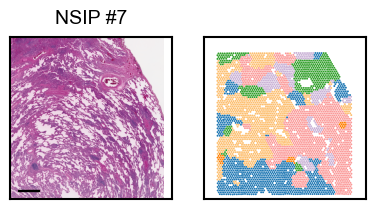

In [ ]:
n_rows, n_cols = 1,2
fig, axes = plt.subplots(n_rows, n_cols, figsize = (2.3 * n_cols, 2.3 * n_rows))

axes = axes.flatten()

scale_bar_length = adata_vis.uns['spatial']['06_30914_A1']['scalefactors']['tissue_hires_scalef'] # Length of the scale bar 
                    # with ax1.transAxes, this is the proportion of the total pixel width
                    # ex. 10th of 14000 px, where each px is 0.5 micron
scale_bar_height = 0.05*scale_bar_length # Height of the scale bar 
                                    
# Create a rectangle for the scale bar on top of the plot
scale_bar = Rectangle(
(0.05,0.05),  # Bottom-left corner of the rectangle (relative coordinates)
width=scale_bar_length,  # Length of the scale bar
height=scale_bar_height,  # Height of the scale bar
transform=axes[0].transAxes,  # Transform relative to the axis
color='black',  # Color of the scale bar
linewidth=1  # Thickness of the scale bar
)


# Add the scale bar to the plot
axes[0].add_patch(scale_bar)
#axes[1].add_patch(scale_bar)




sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "06_30914_A1" ,:], 
    #palette='Paired_r',
    alpha_img=1, 
    library_id = "06_30914_A1",
    size=1.3,
    ax = axes[0],
    #color = "mclust_refined_6",
    # limit color scale at 99.2% quantile of cell abundance
    title = None, 
    vmin='p01', vmax='p99',
    #legend_loc = "lower center",
    show=False)
axes[0].set_title(f"{adata_vis[adata_vis.obs["library_id"]== "06_30914_A1" ,:].obs['lay_id'].unique()[0]}", fontsize = 14, pad = 10)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "06_30914_A1" ,:], 
    palette=color_dict,
    alpha_img=0, 
    library_id = "06_30914_A1",
    size=1.3,
    ax = axes[1],
    color = "mclust_refined_6",
    # limit color scale at 99.2% quantile of cell abundance
    title = None, 
    vmin='p01', vmax='p99',
    legend_loc = None,
    show=False)
axes[1].set_title("")


# axes[1].legend(
#     title="Spatial niches",
#     bbox_to_anchor=(1.5, 1),  # x, y coordinate outside the axes
#     #loc='right',
#     borderaxespad=0.,
#     fontsize=14,
#     title_fontsize =14,
#     frameon = False,
#     ncol =2
# )


for i in range(len(axes)):

    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0,2000)
    axes[i].set_ylim(2000,0)
# axes[6].axis('off')  # Hide the empty axes
#plt.tight_layout(pad=0, w_pad=0.1, h_pad=0.2)
plt.savefig(os.path.join(save_dir,"spatial_plot_spatial_niches_06_30914_A1_NSIP.pdf"), bbox_inches = "tight")


# # Extract handles and labels
# handles, labels = axes[1].get_legend_handles_labels()

# # Create separate figure for legend
# fig_legend = plt.figure(figsize=(4, 2))  # Adjust size as needed
# fig_legend.legend(handles, labels, title="Spatial niche", loc='right', frameon=False, bbox_to_anchor=(1.1, 0.5), ncol=2)  # ncol=2 for horizontal spread

# fig_legend.tight_layout()
# fig_legend.savefig(os.path.join(save_dir, "mclust_6_legend.pdf"), bbox_inches = 'tight', transparent = True)
# fig_legend.show()

/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


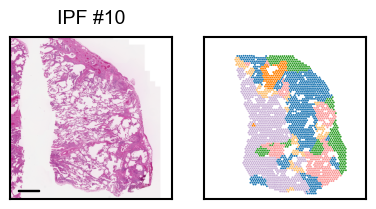

In [ ]:
n_rows, n_cols = 1,2
fig, axes = plt.subplots(n_rows, n_cols, figsize = (2.3 * n_cols, 2.3 * n_rows))

axes = axes.flatten()

scale_bar_length = adata_vis.uns['spatial']['22_16220_B1']['scalefactors']['tissue_hires_scalef'] # Length of the scale bar 
                    # with ax1.transAxes, this is the proportion of the total pixel width
                    # ex. 10th of 14000 px, where each px is 0.5 micron
scale_bar_height = 0.05*scale_bar_length # Height of the scale bar
                                    
# Create a rectangle for the scale bar on top of the plot
scale_bar = Rectangle(
(0.05,0.05),  # Bottom-left corner of the rectangle (relative coordinates)
width=scale_bar_length,  # Length of the scale bar
height=scale_bar_height,  # Height of the scale bar
transform=axes[0].transAxes,  # Transform relative to the axis
color='black',  # Color of the scale bar
linewidth=1  # Thickness of the scale bar
)


# Add the scale bar to the plot
axes[0].add_patch(scale_bar)
#axes[1].add_patch(scale_bar)




sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "22_16220_B1" ,:], 
    #palette='Paired_r',
    alpha_img=1, 
    library_id = "22_16220_B1",
    size=1.3,
    ax = axes[0],
    #color = "mclust_refined_6",
    # limit color scale at 99.2% quantile of cell abundance
    title = None, 
    vmin='p01', vmax='p99',
    #legend_loc = "lower center",
    show=False)
axes[0].set_title(f"{adata_vis[adata_vis.obs["library_id"]== "22_16220_B1" ,:].obs['lay_id'].unique()[0]}", fontsize = 14, pad = 10)

sc.pl.spatial(adata_vis[adata_vis.obs["library_id"]== "22_16220_B1" ,:], 
    palette=color_dict,
    alpha_img=0, 
    library_id = "22_16220_B1",
    size=1.3,
    ax = axes[1],
    color = "mclust_refined_6",
    # limit color scale at 99.2% quantile of cell abundance
    title = None, 
    vmin='p01', vmax='p99',
    legend_loc = None,
    show=False)
axes[1].set_title("")


# axes[1].legend(
#     title="Spatial niches",
#     bbox_to_anchor=(1.5, 1),  # x, y coordinate outside the axes
#     #loc='right',
#     borderaxespad=0.,
#     fontsize=14,
#     title_fontsize =14,
#     frameon = False,
#     ncol =2
# )


for i in range(len(axes)):

    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0,2000)
    axes[i].set_ylim(2000,0)
# axes[6].axis('off')  # Hide the empty axes
#plt.tight_layout(pad=0, w_pad=0.1, h_pad=0.2)
plt.savefig(os.path.join(save_dir,"spatial_plot_spatial_niches_22_16220_B1_CHP.pdf"), bbox_inches = "tight")


# # Extract handles and labels
# handles, labels = axes[1].get_legend_handles_labels()

# # Create separate figure for legend
# fig_legend = plt.figure(figsize=(4, 2))  # Adjust size as needed
# fig_legend.legend(handles, labels, title="Spatial niche", loc='right', frameon=False, bbox_to_anchor=(1.1, 0.5), ncol=2)  # ncol=2 for horizontal spread

# fig_legend.tight_layout()
# fig_legend.savefig(os.path.join(save_dir, "mclust_6_legend.pdf"), bbox_inches = 'tight', transparent = True)
# fig_legend.show()